# Location Selection with E-NAUTILUS: Part 2
_Running of E-NAUTILUS for decision making, and presentation of results_


In [17]:
import numpy as np
import pandas as pd
import polars as pl
import pickle
import folium
# These are to just suppress warnings in the outputs of the example
import warnings

warnings.filterwarnings("ignore")

## Load results from previous session

In [18]:
file_name = "data/pf_test.pkl"

output = open(file_name, 'rb')
prev_session = pickle.load(output)

raw_ref_pf = prev_session["pf"]
prob = prev_session["prob"]
sites = prev_session["sites"]
cities = prev_session["cities"]
cities_adj2sites = prev_session["cities_adj2sites"]


## Load reference front and problem 

In [19]:

output_flat = np.array(raw_ref_pf).flatten()

def process_lists(dict2conv):
    return {key: np.array(dict2conv[key]).flatten().tolist() for key in dict2conv.keys()}

# TODO include constraints in here too
output_dict = [
    output.optimal_objectives | 
    process_lists(output.optimal_variables) 
    for output in output_flat]

results = pl.DataFrame(output_dict)

results = results.unique(subset=("f_1", "f_2", "f_3", "f_4"))

results = results.with_columns([
    (-pl.col("f_1")).alias("f_1_min"),
    (pl.col("f_2")).alias("f_2_min"),
    (pl.col("f_3")).alias("f_3_min"),
    (-pl.col("f_4")).alias("f_4_min")
])

nadir_point = {
  "f_1": float(results["f_1"].min()),
  "f_2": float(results["f_2"].max()),
  "f_3": float(results["f_3"].max()),
  "f_4": float(results["f_4"].min())
}

results = results.unique()

display(results)

print(f"Nadir point: {nadir_point}")
print(f"Nadir point (problem): {prob.get_nadir_point()}")
print(f"Idedal point (problem): {prob.get_ideal_point()}")



f_1,f_2,f_3,f_4,sv,cover,_alpha,f_1_min,f_2_min,f_3_min,f_4_min
f64,f64,f64,f64,list[f64],list[f64],list[f64],f64,f64,f64,f64
182.0,16.0,3727.755,0.0,"[1.0, 1.0, … 1.0]","[-0.0, -0.0, … 0.0]",[308.132484],-182.0,16.0,3727.755,-0.0
118.0,0.0,1877.91,103983.0,"[0.0, 0.0, … 0.0]","[1.0, 1.0, … 0.0]",[0.0],-118.0,0.0,1877.91,-103983.0
104.0,0.0,1608.005,105085.0,"[-0.0, 0.0, … 1.0]","[1.0, 1.0, … 0.0]",[0.428571],-104.0,0.0,1608.005,-105085.0
120.0,0.0,1907.19,105085.0,"[-0.0, 0.0, … 0.0]","[1.0, 1.0, … 0.0]",[0.0],-120.0,0.0,1907.19,-105085.0
12.0,0.0,152.0,6171.0,"[-0.0, 0.0, … -0.0]","[1.0, 1.0, … 0.0]",[0.039601],-12.0,0.0,152.0,-6171.0
…,…,…,…,…,…,…,…,…,…,…
167.0,9.0,3087.855,35999.0,"[-0.0, -0.0, … 1.0]","[-0.0, -0.0, … 0.0]",[0.082418],-167.0,9.0,3087.855,-35999.0
118.0,0.0,1875.1,93425.0,"[-0.0, 0.0, … 1.0]","[1.0, 1.0, … 0.0]",[-0.5],-118.0,0.0,1875.1,-93425.0
54.0,0.0,782.81,69867.0,"[-0.0, 0.0, … 1.0]","[1.0, 1.0, … 0.0]",[0.203946],-54.0,0.0,782.81,-69867.0


Nadir point: {'f_1': 0.0, 'f_2': 16.0, 'f_3': 3727.755, 'f_4': 0.0}
Nadir point (problem): {'f_1': 0, 'f_2': 17, 'f_3': 3838.3199999999997, 'f_4': 0}
Idedal point (problem): {'f_1': 182, 'f_2': 0, 'f_3': 0, 'f_4': 161142}


## Filter out dominated solutions

In [20]:
from pymoo.util.nds.non_dominated_sorting import find_non_dominated

pf = results.select(["f_1", "f_2", "f_3", "f_4"]).to_numpy()

pf_mini = pf.copy()

pf_mini[:,0] = -pf_mini[:,0]
pf_mini[:,3] = -pf_mini[:,3]

nd_inds = find_non_dominated(pf_mini)
display(nd_inds)

nd_df = results[nd_inds,:]
display(nd_df)
nd_df

reachable_indices = list(range(len(nd_df)))  # everything reachable from nadir
reachable_indices


array([ 1,  2,  3,  4,  5,  8,  9, 10, 13, 15, 16, 17, 18, 19, 20, 21, 23,
       24, 25, 26, 28, 29, 30, 34, 36, 37, 38, 41, 42])

f_1,f_2,f_3,f_4,sv,cover,_alpha,f_1_min,f_2_min,f_3_min,f_4_min
f64,f64,f64,f64,list[f64],list[f64],list[f64],f64,f64,f64,f64
118.0,0.0,1877.91,103983.0,"[0.0, 0.0, … 0.0]","[1.0, 1.0, … 0.0]",[0.0],-118.0,0.0,1877.91,-103983.0
104.0,0.0,1608.005,105085.0,"[-0.0, 0.0, … 1.0]","[1.0, 1.0, … 0.0]",[0.428571],-104.0,0.0,1608.005,-105085.0
120.0,0.0,1907.19,105085.0,"[-0.0, 0.0, … 0.0]","[1.0, 1.0, … 0.0]",[0.0],-120.0,0.0,1907.19,-105085.0
12.0,0.0,152.0,6171.0,"[-0.0, 0.0, … -0.0]","[1.0, 1.0, … 0.0]",[0.039601],-12.0,0.0,152.0,-6171.0
97.0,2.0,1667.015,141084.0,"[-0.0, 0.0, … 1.0]","[1.0, 1.0, … 0.0]",[0.472491],-97.0,2.0,1667.015,-141084.0
…,…,…,…,…,…,…,…,…,…,…
52.0,1.0,848.79,127445.0,"[-0.0, 0.0, … -0.0]","[1.0, 1.0, … 0.0]",[0.221136],-52.0,1.0,848.79,-127445.0
118.0,0.0,1883.61,105085.0,"[-0.0, 0.0, … 0.0]","[1.0, 1.0, … 0.0]",[0.0],-118.0,0.0,1883.61,-105085.0
52.0,1.0,830.9,119757.0,"[-0.0, 0.0, … -0.0]","[1.0, 1.0, … 0.0]",[-0.283525],-52.0,1.0,830.9,-119757.0


[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28]

## Analyze PF 


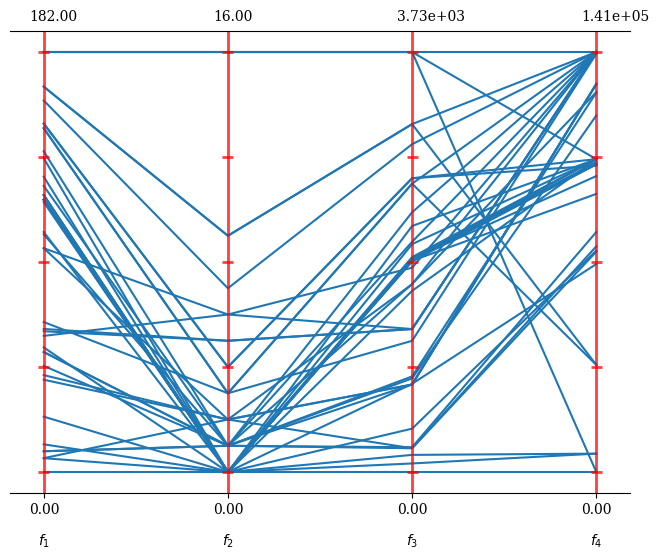

In [21]:
from pymoo.visualization.pcp import PCP
PCP().add(pf).show()

## Helper functions

In [22]:
# Function to determine marker size based on population
def get_marker_size(population):
    return max(5, population / 1000)  # Adjust the divisor to scale marker size

def create_color_dict(cities, ev_cities, cc): 
    marker_color = {}
    for city in cities.loc[:,"city"]: 
        if city in ev_cities: 
            marker_color[city] = "orange"
        elif city in cc: 
            marker_color[city] = "yellow"
        else: 
            marker_color[city] = "grey"

    return marker_color

def select_point(results, sol_id): 

    return {
        "f_1": int(results.loc[sol_id, "Total patients served"]),
        "f_2": int(results.loc[sol_id, "# of visited sites that are under-attended"]),
        "f_3": float(results.loc[sol_id, "Total costs ($)"]),
        "f_4": float(results.loc[sol_id, "Population with clinic access"])
        }


def clean_results(raw_results, intermediate_point=True): 
    # Transform objectives
    if intermediate_point: 
        results = pd.DataFrame(raw_results.intermediate_points)
    else:
        results = pd.DataFrame(raw_results.optimal_objectives)

    results = results.rename(columns={
                    "f_1": "Total patients served", 
                    "f_2": "# of visited sites that are under-attended", 
                    "f_3": "Total costs ($)", 
                    "f_4": "Population with clinic access"})

    results[["Total patients served"]] =  results[["Total patients served"]].astype(int)
    results[["Total costs ($)"]] = (results[["Total costs ($)"]]).round(2)

    results.index.name = "Solution ID"

    return results

## Calculate HV

In [23]:
from pymoo.indicators.hv import HV

ref_point = np.array(list(nadir_point.values()))
ref_point[0] = -ref_point[0]
ref_point[3] = -ref_point[3]

ind = HV(ref_point=ref_point)

int(ind(pf))

0

## Run eNAUTILUS 
### Round 1
We're going to generate some solutions. They will be poor at first, but you and the computer will slowly find the best solution that fulfills your goals and preferences. 


In [24]:
# Initialize a first solution 
from desdeo.mcdm.enautilus import enautilus_step
from desdeo.mcdm.enautilus import enautilus_get_representative_solutions

current_iter = 0
selected_point = nadir_point
total_iterations = 3
display(f"Starting with point {selected_point}")

prob.get_ideal_point()

raw_results = enautilus_step(
    problem=prob,
    non_dominated_points=nd_df,
    current_iteration=current_iter,
    iterations_left=total_iterations - current_iter,
    selected_point=selected_point,
    reachable_point_indices=reachable_indices,
    total_number_of_iterations=total_iterations,
    number_of_intermediate_points=3,
)

print(f"number of iterations left: {total_iterations - current_iter}")

results = clean_results(raw_results)
display("Which solution to do you prefer?")
display(results)

"Starting with point {'f_1': 0.0, 'f_2': 16.0, 'f_3': 3727.755, 'f_4': 0.0}"

number of iterations left: 3


'Which solution to do you prefer?'

,Total patients served,# of visited sites that are under-attended,Total costs ($),Population with clinic access
Solution ID,,,,
0,2,10.666667,2510.50,2057.000000
1,21,11.666667,2873.32,46827.666667
2,39,10.666667,3108.53,34460.666667


### Round 2 

In [25]:
chosen_solution = 1

In [26]:
# Refine solution based on feedback
current_iter += 1
selected_point = select_point(results, chosen_solution)

print(selected_point)

raw_results = enautilus_step(
    problem=prob,
    non_dominated_points=nd_df,
    current_iteration=current_iter,
    iterations_left=total_iterations - current_iter,
    selected_point=selected_point,
    reachable_point_indices=reachable_indices,
    total_number_of_iterations=total_iterations,
    number_of_intermediate_points=3,
)

print(f"number of iterations left: {total_iterations - current_iter}")
display(raw_results)
results = clean_results(raw_results)
display("Which solution to do you find most preferable?")
display(results)
display("Results:")



{'f_1': 21, 'f_2': 11, 'f_3': 2873.32, 'f_4': 46827.666666666664}
number of iterations left: 2


ENautilusResult(current_iteration=2, iterations_left=1, intermediate_points=[{'f_1': 13.5, 'f_2': 5.5, 'f_3': 1474.66, 'f_4': 26499.333333333332}, {'f_1': 43.0, 'f_2': 7.0, 'f_3': 2018.8775, 'f_4': 93655.33333333333}, {'f_1': 69.5, 'f_2': 5.5, 'f_3': 2371.7025000000003, 'f_4': 75104.83333333333}], reachable_best_bounds=[{'f_1': 65.0, 'f_2': 0.0, 'f_3': 384.76, 'f_4': 141084.0}, {'f_1': 120.0, 'f_2': 0.0, 'f_3': 776.325, 'f_4': 141084.0}, {'f_1': 139.0, 'f_2': 0.0, 'f_3': 1608.005, 'f_4': 141084.0}], reachable_worst_bounds=[{'f_1': 13.5, 'f_2': 5.5, 'f_3': 1474.66, 'f_4': 26499.333333333332}, {'f_1': 43.0, 'f_2': 7.0, 'f_3': 2018.8775, 'f_4': 93655.33333333333}, {'f_1': 69.5, 'f_2': 5.5, 'f_3': 2371.7025000000003, 'f_4': 75104.83333333333}], closeness_measures=[370.8911449931759, 66.66666654725168, 72.64797871120366], reachable_point_indices=[[5, 6, 18, 21, 24, 26, 27], [0, 1, 2, 4, 5, 6, 12, 14, 18, 24, 25, 26, 27, 28], [0, 1, 2, 4, 10, 12, 14, 15, 16, 23, 25, 28]])

'Which solution to do you find most preferable?'

,Total patients served,# of visited sites that are under-attended,Total costs ($),Population with clinic access
Solution ID,,,,
0,13,5.5,1474.66,26499.333333
1,43,7.0,2018.88,93655.333333
2,69,5.5,2371.70,75104.833333


'Results:'

### Round 3

In [27]:
chosen_solution = 1

In [28]:
# Refine solution based on feedback
current_iter += 1
selected_point = select_point(results, chosen_solution)

print(selected_point)

raw_results = enautilus_step(
    problem=prob,
    non_dominated_points=nd_df,
    current_iteration=current_iter,
    iterations_left=total_iterations - current_iter,
    selected_point=selected_point,
    reachable_point_indices=reachable_indices,
    total_number_of_iterations=total_iterations,
    number_of_intermediate_points=3,
)

print(f"number of iterations left: {total_iterations - current_iter}")

results = clean_results(raw_results)
display("Which solution to do you find most preferable?")
display(results)




{'f_1': 43, 'f_2': 7, 'f_3': 2018.88, 'f_4': 93655.33333333333}
number of iterations left: 1


'Which solution to do you find most preferable?'

,Total patients served,# of visited sites that are under-attended,Total costs ($),Population with clinic access
Solution ID,,,,
0,6,0.0,76.00,6171.0
1,65,3.0,1164.44,140483.0
2,118,0.0,1870.08,103382.0


## Display final result

In [29]:
final_chosen_solution = 1

In [30]:
# Get final solution 
solutions = enautilus_get_representative_solutions(prob, raw_results, nd_df) 
solution = solutions[final_chosen_solution]
results = clean_results(solution, intermediate_point=False)

display(results)
 


,Total patients served,# of visited sites that are under-attended,Total costs ($),Population with clinic access
Solution ID,,,,
0,65,3.0,1164.44,140483.0


### Result postprocessing

In [31]:
# Post process result...
raw_sites = solution.optimal_variables['sv'][0].to_list()
raw_sites = [[bool(e) for e in raw_sites]]

raw_coverage = solution.optimal_variables['cover'][0].to_list()
raw_coverage = [[bool(c) for c in raw_coverage]]

sites_visited = []
for evb in raw_sites: 
    sites_visited.append("\n".join(sites.loc[evb, "site_id"].values))

cities_covered = [] 
for cc in raw_coverage: 
    cities_covered.append("\n".join(cities.loc[cc,"city"].values))

results["Sites Visited"] = sites_visited
results["Cities covered"] = cities_covered

results

,Total patients served,# of visited sites that are under-attended,Total costs ($),Population with clinic access,Sites Visited,Cities covered
Solution ID,,,,,,
0,65,3.0,1164.44,140483.0,lima-lima-library\nbluffton-bluffton-library\n...,Ada\nAlger\nBluffton\nCairo\nColumbus Grove\nC...


### Map preprocessing

In [32]:
# Process for the map
sites_in_cities = sites.loc[raw_sites[0],:].groupby("city").agg({"site_pretty": lambda e : '<br>'.join(e)})
sites_in_cities = sites_in_cities.to_dict()['site_pretty']
sites_in_cities

# cc cities covered
cc = set(cities_covered[0].split('\n'))

site_cities = list(sites.loc[raw_sites[0], "city"])
marker_colors = create_color_dict(cities, site_cities, cc)


## Site coverage dictionary 
site2city_mat = cities_adj2sites[raw_sites[0]].astype(bool)

site2city_dict = {}
for (c,city) in enumerate(site_cities): 
    site2city_dict[city] = set(cities.loc[site2city_mat[c,],"city"]) - {city}

adjacent_sites = {}
# Record what sites are near other cities
for site_city in site2city_dict.keys(): 
    adj_cities = site2city_dict[site_city]
    from_name = cities.loc[cities.loc[:,"city"] == site_city,["city"]].values.tolist()[0][0]

    for adj_city in adj_cities: 
        to_name = cities.loc[cities.loc[:,"city"] == adj_city ,["city"]].values.tolist()[0][0]

        if to_name not in adjacent_sites.keys(): 
            adjacent_sites[to_name] = {from_name}
        else: 
            adjacent_sites[to_name] = adjacent_sites[to_name].union({from_name})



## Render map

In [33]:
# Render map

# Create a base map
m = folium.Map(location=[cities['lat'].mean(), 
                         cities['long'].mean()], 
                         zoom_start=7) 

# Draw lines between 
for site_city in site2city_dict.keys(): 
    adj_cities = site2city_dict[site_city]
    from_loc = cities.loc[cities.loc[:,"city"] == site_city,["lat", "long"]].values.tolist()

    for adj_city in adj_cities: 
        to_loc = cities.loc[cities.loc[:,"city"] == adj_city ,["lat", "long"]].values.tolist()
        folium.PolyLine(
            locations=[to_loc[0], from_loc[0]],
            color="black"
        ).add_to(m)

# Set bounds
sw = cities.loc[:,['lat', 'long']].min().values.tolist()
ne = cities.loc[:,['lat', 'long']].max().values.tolist()
m.fit_bounds([sw,ne])

# Create tool tips 
tooltips = {}
for _, row in cities.iterrows():
    city = row['city']
    tooltips[city]=f"<b>{city}</b><br><b>Population:</b> {row['pop']}"

    if city in sites_in_cities.keys():
        tooltips[city]+= "<br><b>Sites with events:</b><br>"
        tooltips[city]+= sites_in_cities[city]
    else:
        tooltips[city]+= "<br><b>No Healthwise Clinics</b>"

    if city in adjacent_sites.keys(): 
        tooltips[city]+= "<br><b>Covered by events in: </b>"
        tooltips[city]+= "<br>".join(adjacent_sites[city])


# Add cities to the map
for _, row in cities.iterrows():
    city = row['city']
    folium.CircleMarker(
        location=(row['lat'], row['long']),
        radius=get_marker_size(row['pop']),
        color="black",
        fill=True,
        fill_color=marker_colors[city],
        fill_opacity=0.6,
        tooltip=tooltips[city]
    ).add_to(m)

display(results)
display(m)

,Total patients served,# of visited sites that are under-attended,Total costs ($),Population with clinic access,Sites Visited,Cities covered
Solution ID,,,,,,
0,65,3.0,1164.44,140483.0,lima-lima-library\nbluffton-bluffton-library\n...,Ada\nAlger\nBluffton\nCairo\nColumbus Grove\nC...
